## Forecasting

Se realizó un análisis de predicción utilizando una serie temporal basada en la producción promedio de café por año.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("../dataset/coffee_cleaned.csv")
df.head()

,country,year,arabica_production,bean_exports,bean_imports,beginning_stocks,domestic_consumption,ending_stocks,exports,imports,...,production,roast_and_ground_exports,roast_and_ground_imports,robusta_production,rstground_dom_consum,soluble_dom_cons,soluble_exports,soluble_imports,total_distribution,total_supply
0,Albania,1960,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Albania,1961,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Albania,1962,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Albania,1963,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Albania,1964,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_year = df.groupby('year')['production'].mean().reset_index()
df_year.head()

,year,production
0,1960,695.117021
1,1961,807.212766
2,1962,721.074468
3,1963,694.627660
4,1964,559.702128


In [4]:
X = df_year[['year']]
y = df_year['production']

## Modelo de regresión

Se utilizó un modelo de regresión lineal para analizar la tendencia de la producción a lo largo del tiempo.

In [5]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predicción

El modelo se utilizó para estimar la producción de café en años futuros.

In [6]:
future_years = pd.DataFrame({'year': [2025, 2026, 2027]})
predictions = model.predict(future_years)

predictions

array([1772.10379598, 1791.25611337, 1810.40843075])

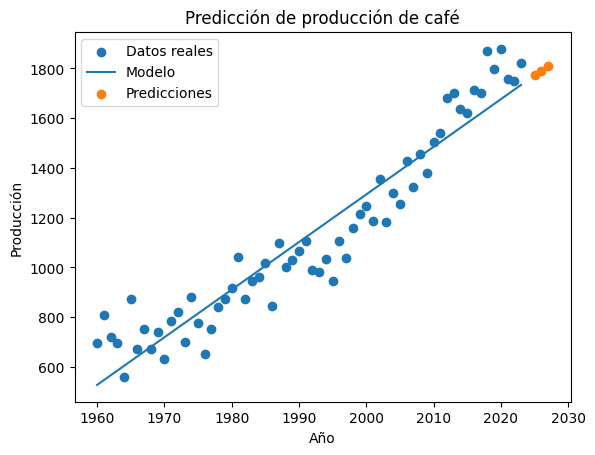

In [7]:
plt.scatter(X, y, label="Datos reales")
plt.plot(X, model.predict(X), label="Modelo")

plt.scatter(future_years, predictions, label="Predicciones")

plt.legend()
plt.title("Predicción de producción de café")
plt.xlabel("Año")
plt.ylabel("Producción")
plt.show()

## Interpretación de resultados

La gráfica muestra una tendencia creciente en la producción de café a lo largo de los años.

El modelo de regresión lineal se ajusta adecuadamente a los datos, lo que indica que existe una relación positiva entre el tiempo y la producción.

Las predicciones para años futuros siguen esta tendencia, lo que sugiere que la producción continuará en aumento si las condiciones actuales se mantienen.

## Conclusiones

El modelo de forecasting permitió identificar una tendencia positiva en la producción de café a lo largo del tiempo.

Los resultados indican que la producción ha ido incrementando de manera constante y que es posible estimar valores futuros mediante regresión lineal.

Este tipo de análisis es útil para la toma de decisiones y planificación a largo plazo en la industria cafetera.